In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [9]:
df.groupby("Pclass")["Survived"].agg(["count", "mean"])

,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


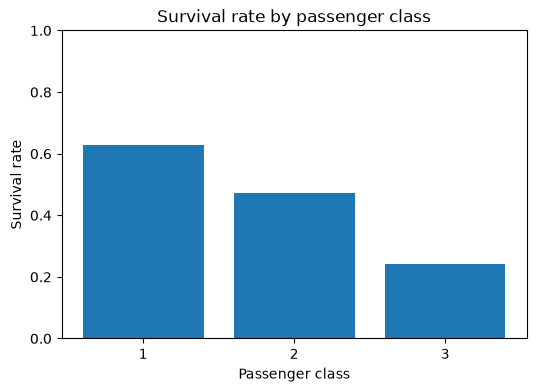

In [10]:
stats = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6, 4))
plt.bar(stats.index.astype(str), stats.values)

plt.title("Survival rate by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

In [11]:
df.groupby("Sex")["Survived"].agg(["count", "mean"])

,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


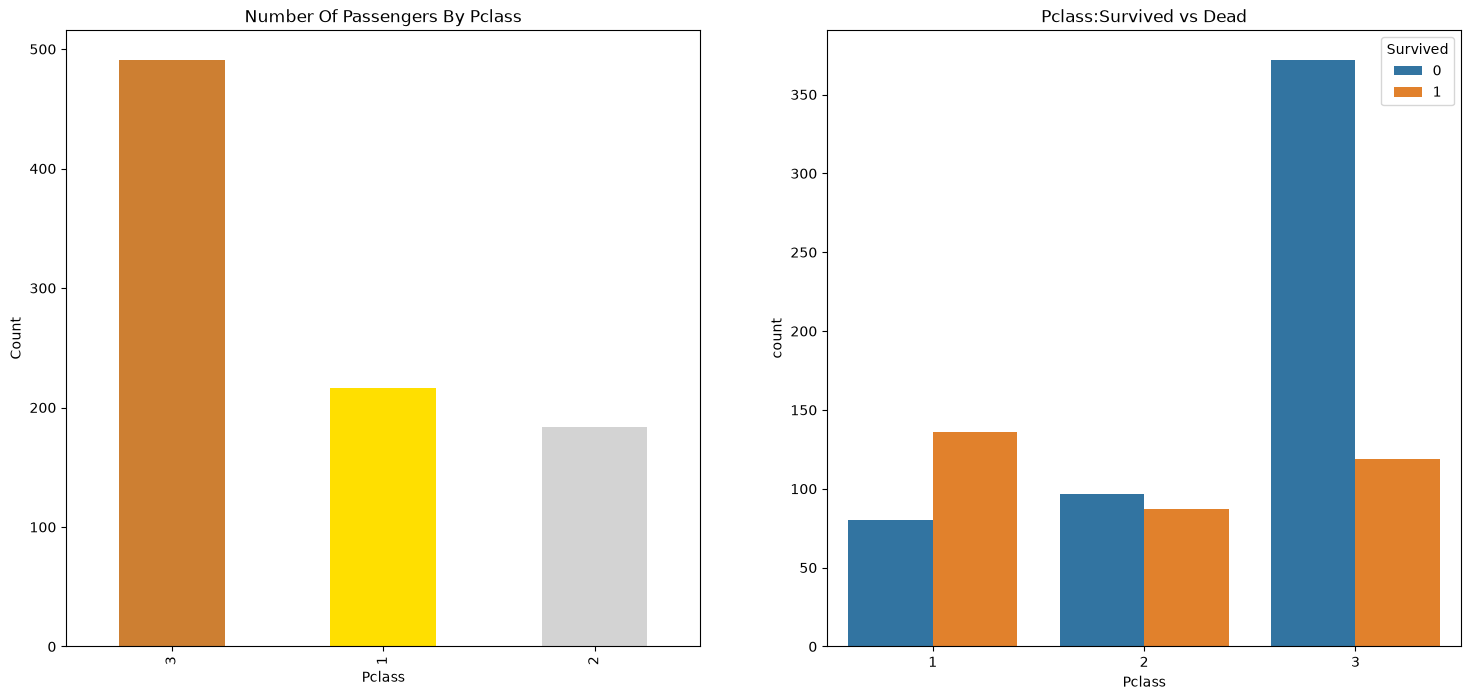

In [12]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=df,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

In [13]:
pd.crosstab([df.Sex,df.Survived],df.Pclass,margins=True).style.background_gradient(cmap='summer_r')

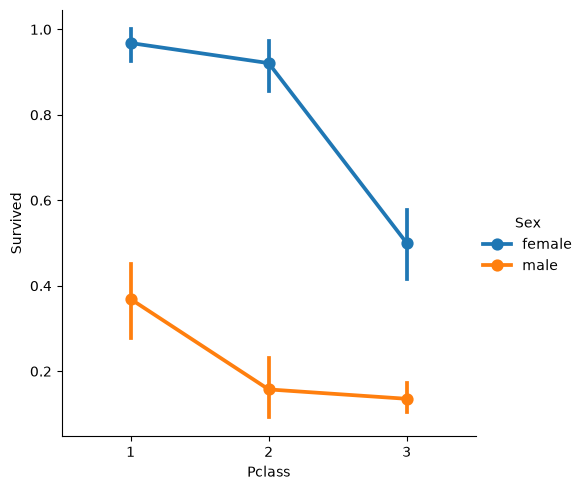

In [14]:
sns.catplot(data=df,x='Pclass',y='Survived',hue='Sex', kind="point")
plt.show()

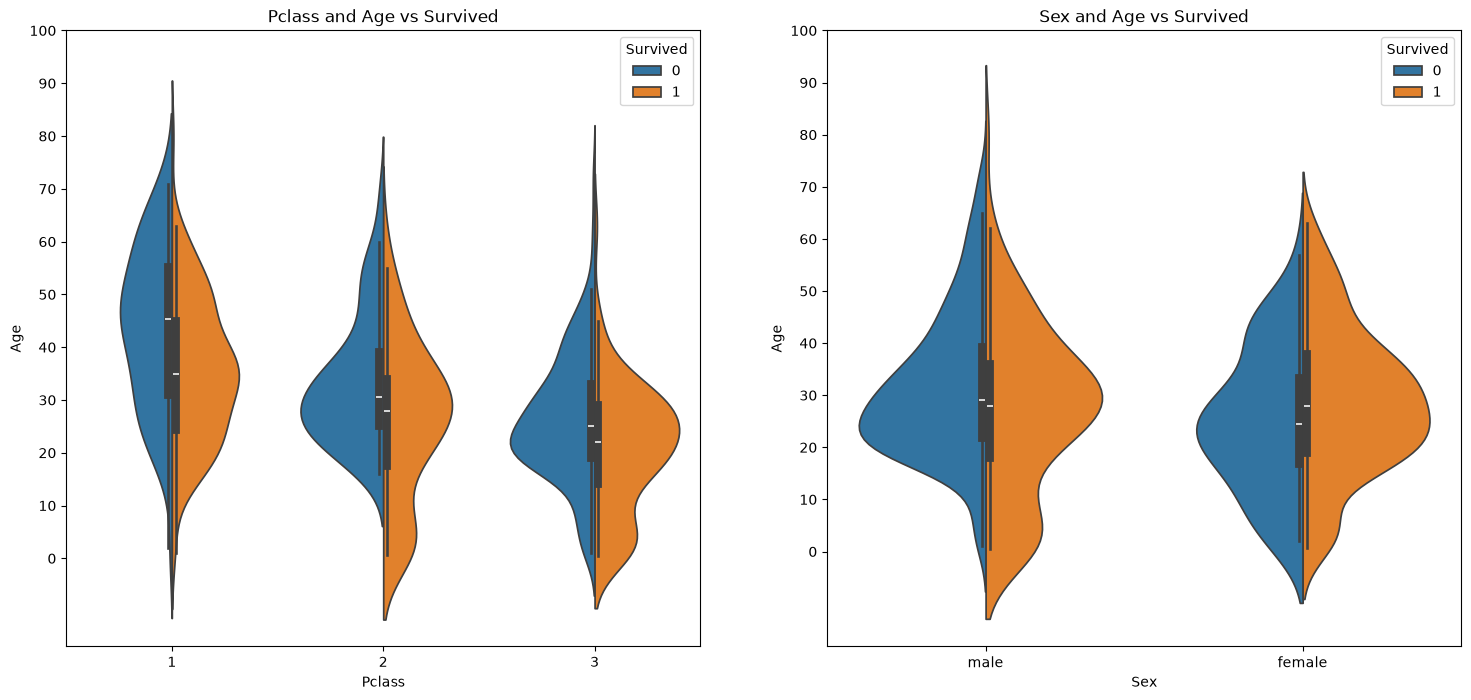

In [15]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=df,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age", hue="Survived", data=df,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

In [16]:
df['Initial']=0
for i in df:
    df['Initial']=df.Name.str.extract('([A-Za-z]+)\.')

In [17]:
pd.crosstab(df.Initial,df.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [18]:
df["Initial"] = df["Initial"].replace(
    {
        "Mlle": "Miss",
        "Mme": "Miss",
        "Ms": "Miss",
        "Dr": "Mr",
        "Major": "Mr",
        "Lady": "Mrs",
        "Countess": "Mrs",
        "Jonkheer": "Other",
        "Col": "Other",
        "Rev": "Other",
        "Capt": "Mr",
        "Sir": "Mr",
        "Don": "Mr"
    }
)

In [19]:
df.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [20]:
df.loc[(df.Age.isnull())&(df.Initial=='Mr'),'Age'] = 33
df.loc[(df.Age.isnull())&(df.Initial=='Mrs'),'Age'] = 36
df.loc[(df.Age.isnull())&(df.Initial=='Master'),'Age'] = 5
df.loc[(df.Age.isnull())&(df.Initial=='Miss'),'Age']  = 22
df.loc[(df.Age.isnull())&(df.Initial=='Other'),'Age'] = 46

In [21]:
df.Age.isnull().any()

np.False_

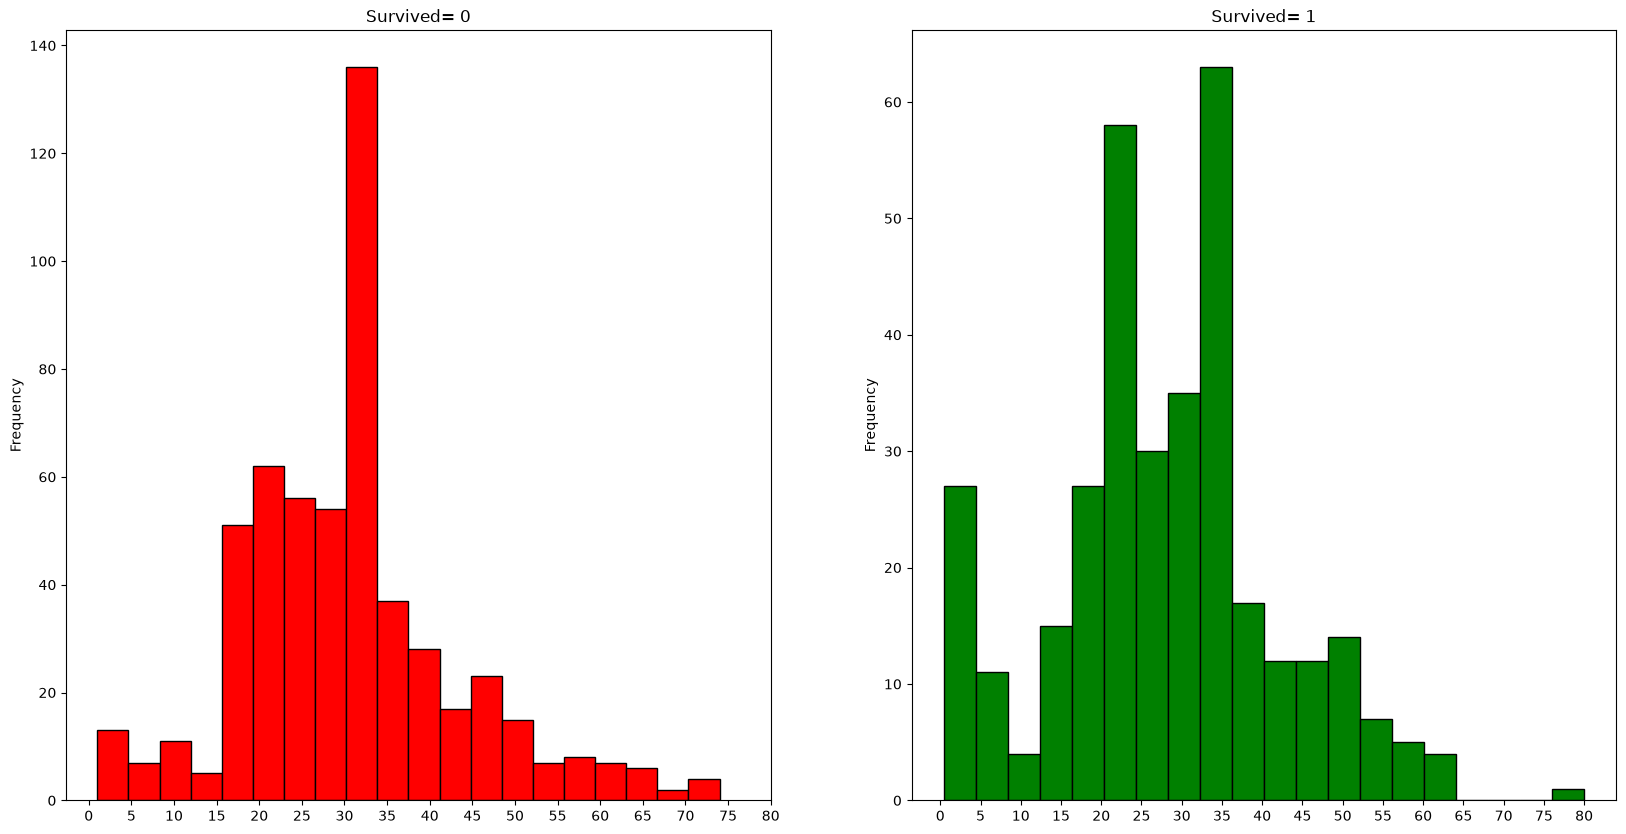

In [22]:
f,ax=plt.subplots(1,2,figsize=(20,10))
df[df['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
df[df['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

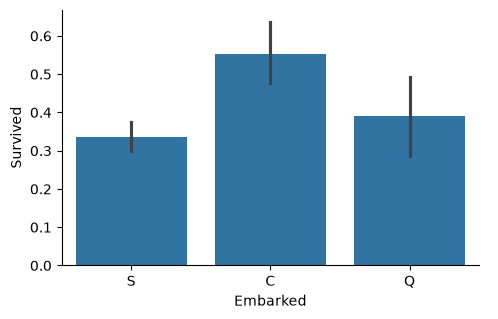

In [23]:
sns.catplot(data=df,x='Embarked',y='Survived', kind="bar")
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

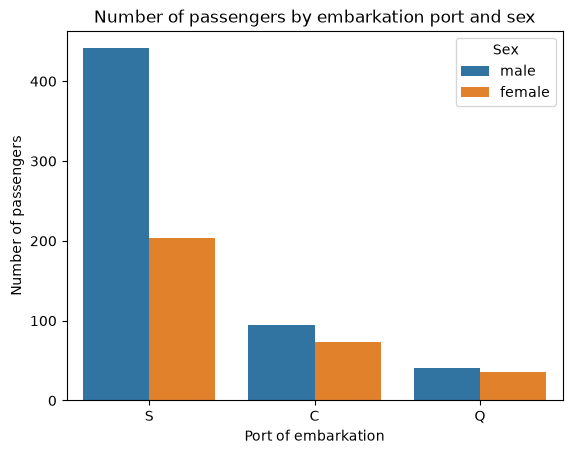

In [24]:
sns.countplot(data=df,x="Embarked",hue="Sex")

plt.title("Number of passengers by embarkation port and sex")
plt.xlabel("Port of embarkation")
plt.ylabel("Number of passengers")

plt.show()

In [25]:
df["Embarked"] = df['Embarked'].fillna('S')

In [26]:
df["Embarked"].isnull().any()

np.False_

In [27]:
pd.crosstab(df.SibSp, df.Survived)

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


In [28]:
pd.crosstab(df.Parch, df.Survived)

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


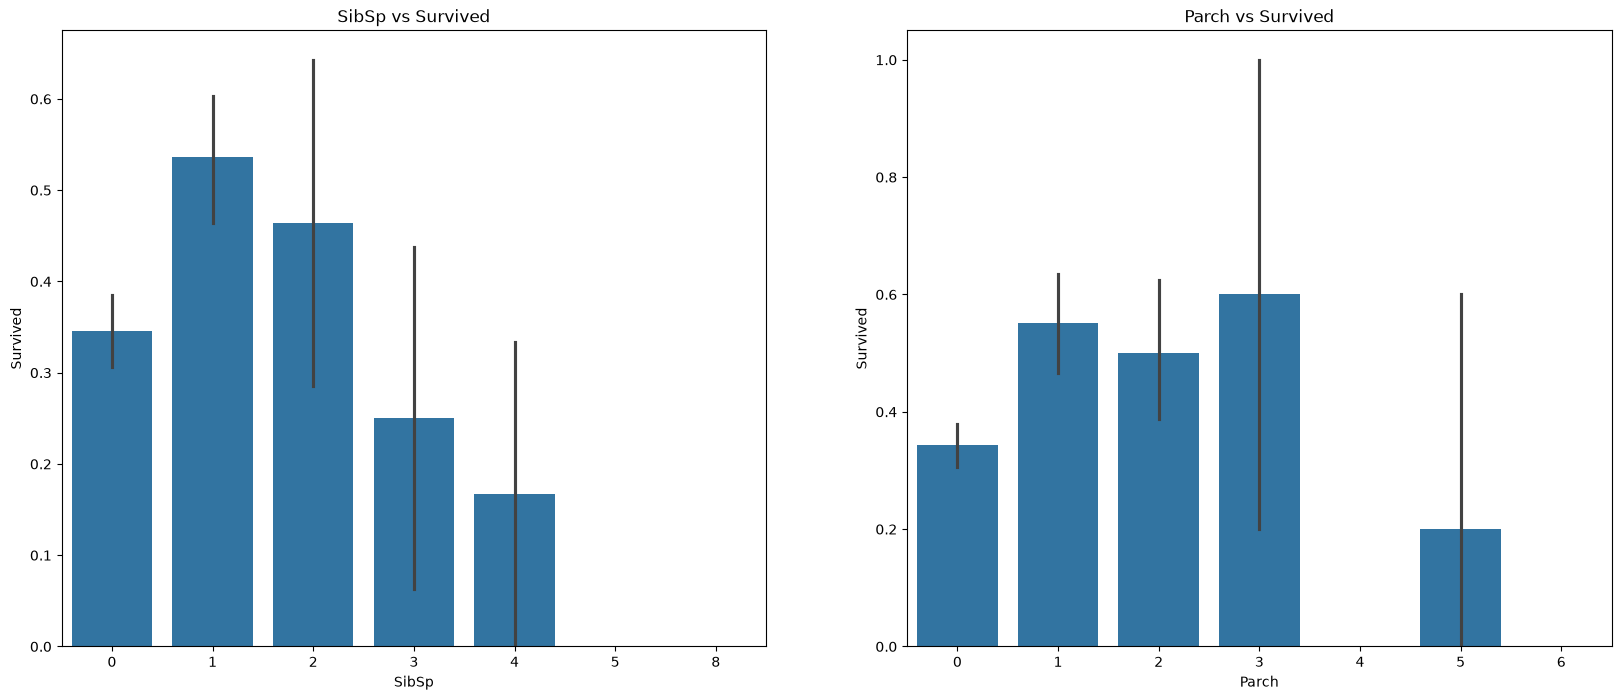

In [29]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot(data=df, x='SibSp', y='Survived', ax=ax[0])
ax[0].set_title('SibSp vs Survived')
sns.barplot(data=df, x='Parch', y='Survived', ax=ax[1])
ax[1].set_title('Parch vs Survived')
plt.close(2)
plt.show()

In [30]:
pd.crosstab(df.SibSp, df.Pclass)

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


In [31]:
pd.crosstab(df.Parch, df.Pclass)

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


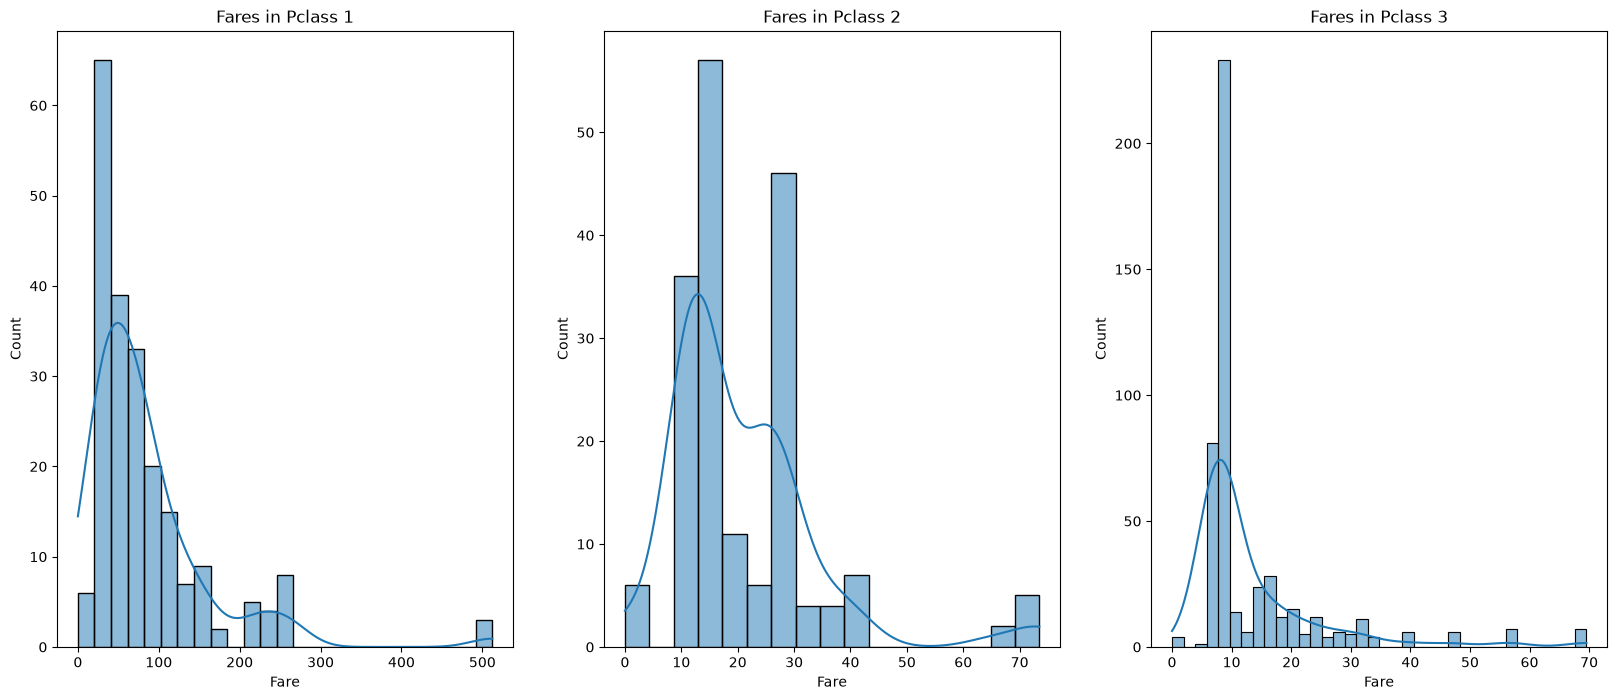

In [32]:
f, ax = plt.subplots(1, 3, figsize=(20, 8))
sns.histplot(df[df['Pclass']==1].Fare, ax=ax[0], kde=True)
ax[0].set_title('Fares in Pclass 1')
sns.histplot(df[df['Pclass']==2].Fare, ax=ax[1], kde=True)
ax[1].set_title('Fares in Pclass 2')
sns.histplot(df[df['Pclass']==3].Fare, ax=ax[2], kde=True)
ax[2].set_title('Fares in Pclass 3')
plt.show()

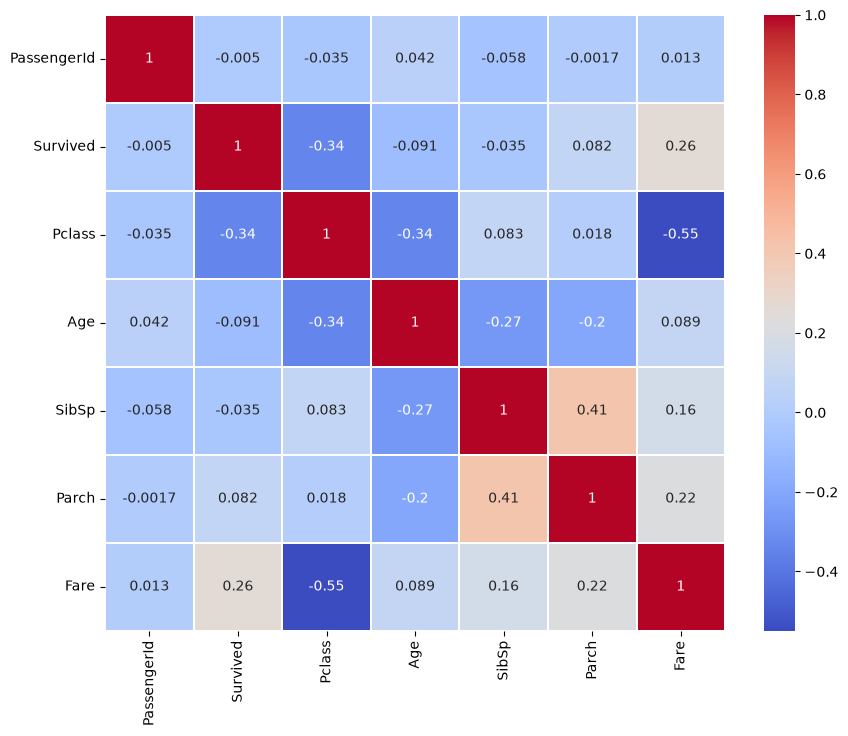

In [33]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

In [34]:
df["Age_bin"] = pd.cut(df["Age"], bins=[0,10,20,30,40,50,60,70,80])
df.groupby("Age_bin", observed=True)["Survived"].agg(["count", "mean"])

,count,mean
Age_bin,,
"(0, 10]",68,0.588235
"(10, 20]",115,0.382609
"(20, 30]",266,0.398496
"(30, 40]",292,0.332192
"(40, 50]",86,0.383721
"(50, 60]",42,0.404762
"(60, 70]",17,0.235294
"(70, 80]",5,0.200000


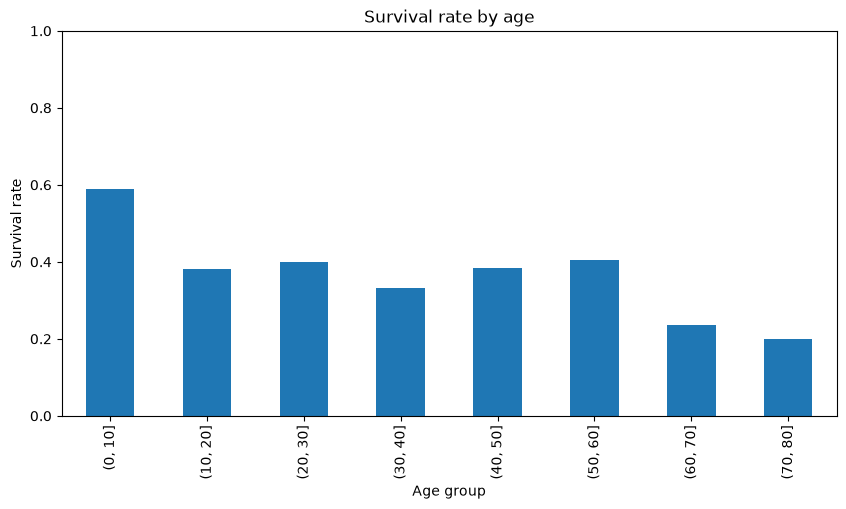

In [35]:
age_stats = df.groupby("Age_bin", observed=True)["Survived"].mean()

plt.figure(figsize=(10, 5))
age_stats.plot(kind="bar")

plt.title("Survival rate by age")
plt.xlabel("Age group")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

In [36]:
df.groupby(["Sex", "Age_bin"])["Survived"].agg(["count", "mean"]).style.background_gradient(cmap="summer_r")

In [37]:
tables = [
    df[df["Pclass"] == pclass].groupby(["Sex", "Age_bin"])["Survived"].agg(["count", "mean"]) 
    for pclass in sorted(df["Pclass"].unique())
]
result = pd.concat(tables, axis=1, keys=[f"Pclass {p}" for p in sorted(df["Pclass"].unique())])
result.style.format({
    col: "{:.0f}" if col[1] == "count" else "{:.2f}"
    for col in result.columns
    }, na_rep="").background_gradient(cmap="summer_r")

In [38]:
tables = [
    df[df["Pclass"] == pclass].groupby(["Age_bin"])["Survived"].agg(["count", "mean"]) 
    for pclass in sorted(df["Pclass"].unique())
]
result = pd.concat(tables, axis=1, keys=[f"Pclass {p}" for p in sorted(df["Pclass"].unique())])
result.style.format({
    col: "{:.0f}" if col[1] == "count" else "{:.2f}"
    for col in result.columns
    }, na_rep="").background_gradient(cmap="summer_r")

In [39]:
df['Age_range']=0
df.loc[df['Age'] <= 16, 'Age_range'] = 0
df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age_range'] = 1
df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age_range'] = 2
df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age_range'] = 3
df.loc[df['Age'] > 64, 'Age_range'] = 4
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_bin,Age_range
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,"(20, 30]",1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"(30, 40]",2


In [40]:
df['Age_range'].value_counts()

Age_range
1    382
2    325
0    104
3     69
4     11
Name: count, dtype: int64

In [41]:
df.groupby("Age_range")["Survived"].agg(["count", "mean"])

,count,mean
Age_range,,
0,104,0.548077
1,382,0.392670
2,325,0.320000
3,69,0.434783
4,11,0.090909


In [42]:
df.groupby("Age_bin")["Survived"].agg(["count", "mean"])

,count,mean
Age_bin,,
"(0, 10]",68,0.588235
"(10, 20]",115,0.382609
"(20, 30]",266,0.398496
"(30, 40]",292,0.332192
"(40, 50]",86,0.383721
"(50, 60]",42,0.404762
"(60, 70]",17,0.235294
"(70, 80]",5,0.200000


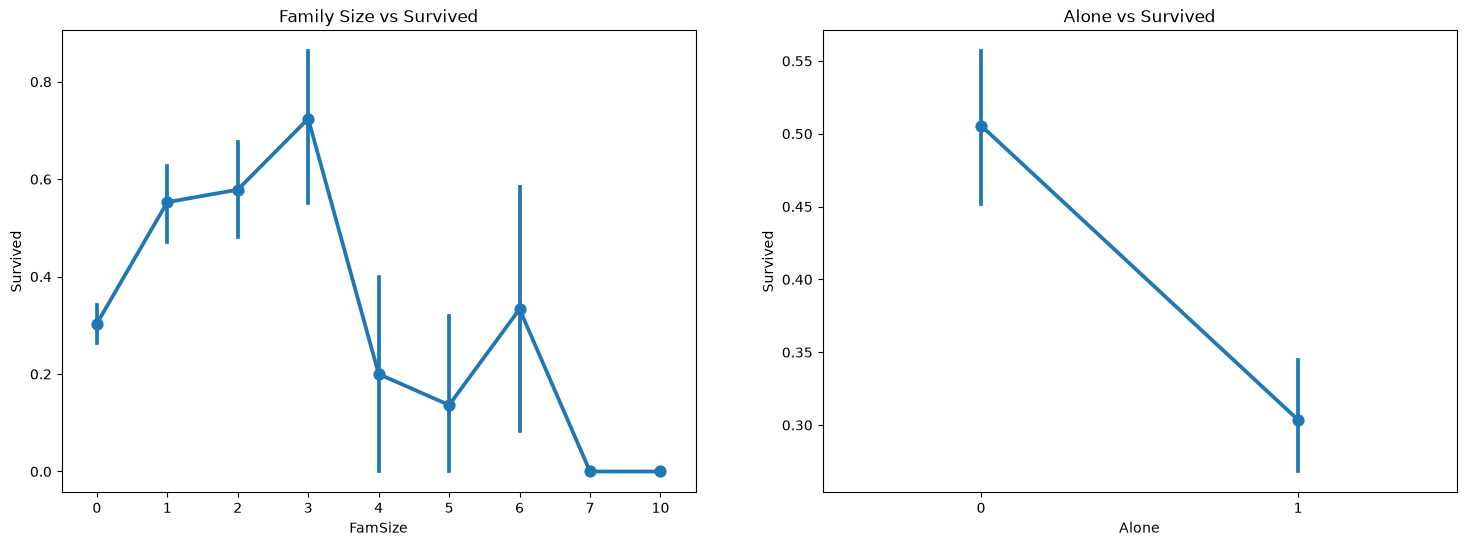

In [44]:
df['FamSize'] = 0
df['FamSize'] = df['Parch'] + df['SibSp']
df['Alone'] = 0
df.loc[df['FamSize'] == 0, 'Alone'] = 1

f, ax=plt.subplots(1,2,figsize=(18,6))
sns.pointplot(data=df,x='FamSize',y='Survived', ax=ax[0])
ax[0].set_title('Family Size vs Survived')
sns.pointplot(data=df,x='Alone',y='Survived', ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

In [45]:
df.groupby(["Sex", "Pclass", "Alone"])["Survived"].agg(["count", "mean"])

count      mean
Sex    Pclass Alone                 
female 1      0         60  0.966667
              1         34  0.970588
       2      0         44  0.931818
              1         32  0.906250
       3      0         84  0.416667
              1         60  0.616667
male   1      0         47  0.425532
              1         75  0.333333
       2      0         36  0.277778
              1         72  0.097222
       3      0         83  0.180723
              1        264  0.121212

In [46]:
tables = [
    df[df["Pclass"] == pclass].groupby(["FamSize", "Sex"])["Survived"].agg(["count", "mean"]) 
    for pclass in sorted(df["Pclass"].unique())
]
result = pd.concat(tables, axis=1, keys=[f"Pclass {p}" for p in sorted(df["Pclass"].unique())])
result.style.format({
    col: "{:.0f}" if col[1] == "count" else "{:.2f}"
    for col in result.columns
    }, na_rep="").background_gradient(cmap="summer_r")

In [103]:
df['Fare_range'] = pd.qcut(df['Fare'], 4)
df.groupby('Fare_range')['Survived'].mean().to_frame()

,Survived
Fare_range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


In [104]:
df['Fare_cat'] = 0
df.loc[df['Fare'] <= 7.91, 'Fare_cat'] = 0
df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.454), 'Fare_cat'] = 1
df.loc[(df['Fare'] > 14.454) & (df['Fare'] <= 31), 'Fare_cat'] = 2
df.loc[df['Fare'] > 31, 'Fare_cat'] = 3

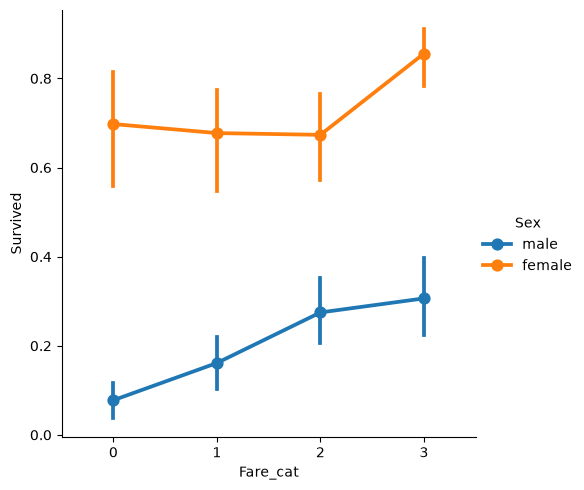

In [105]:
sns.catplot(data=df,x='Fare_cat',y='Survived',kind="point", hue='Sex')

In [106]:
df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})
df['Initial'] = df['Initial'].replace({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Other': 4})
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_range,FamSize,Alone,Fare_range,Fare_cat
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1,1,0,"(-0.001, 7.91]",0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,2,2,1,0,"(31.0, 512.329]",3
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,0,1,"(7.91, 14.454]",1


In [107]:
df.drop(['Name','Age','Ticket','Fare','Cabin', 'Fare_range', 'PassengerId'],axis=1,inplace=True)

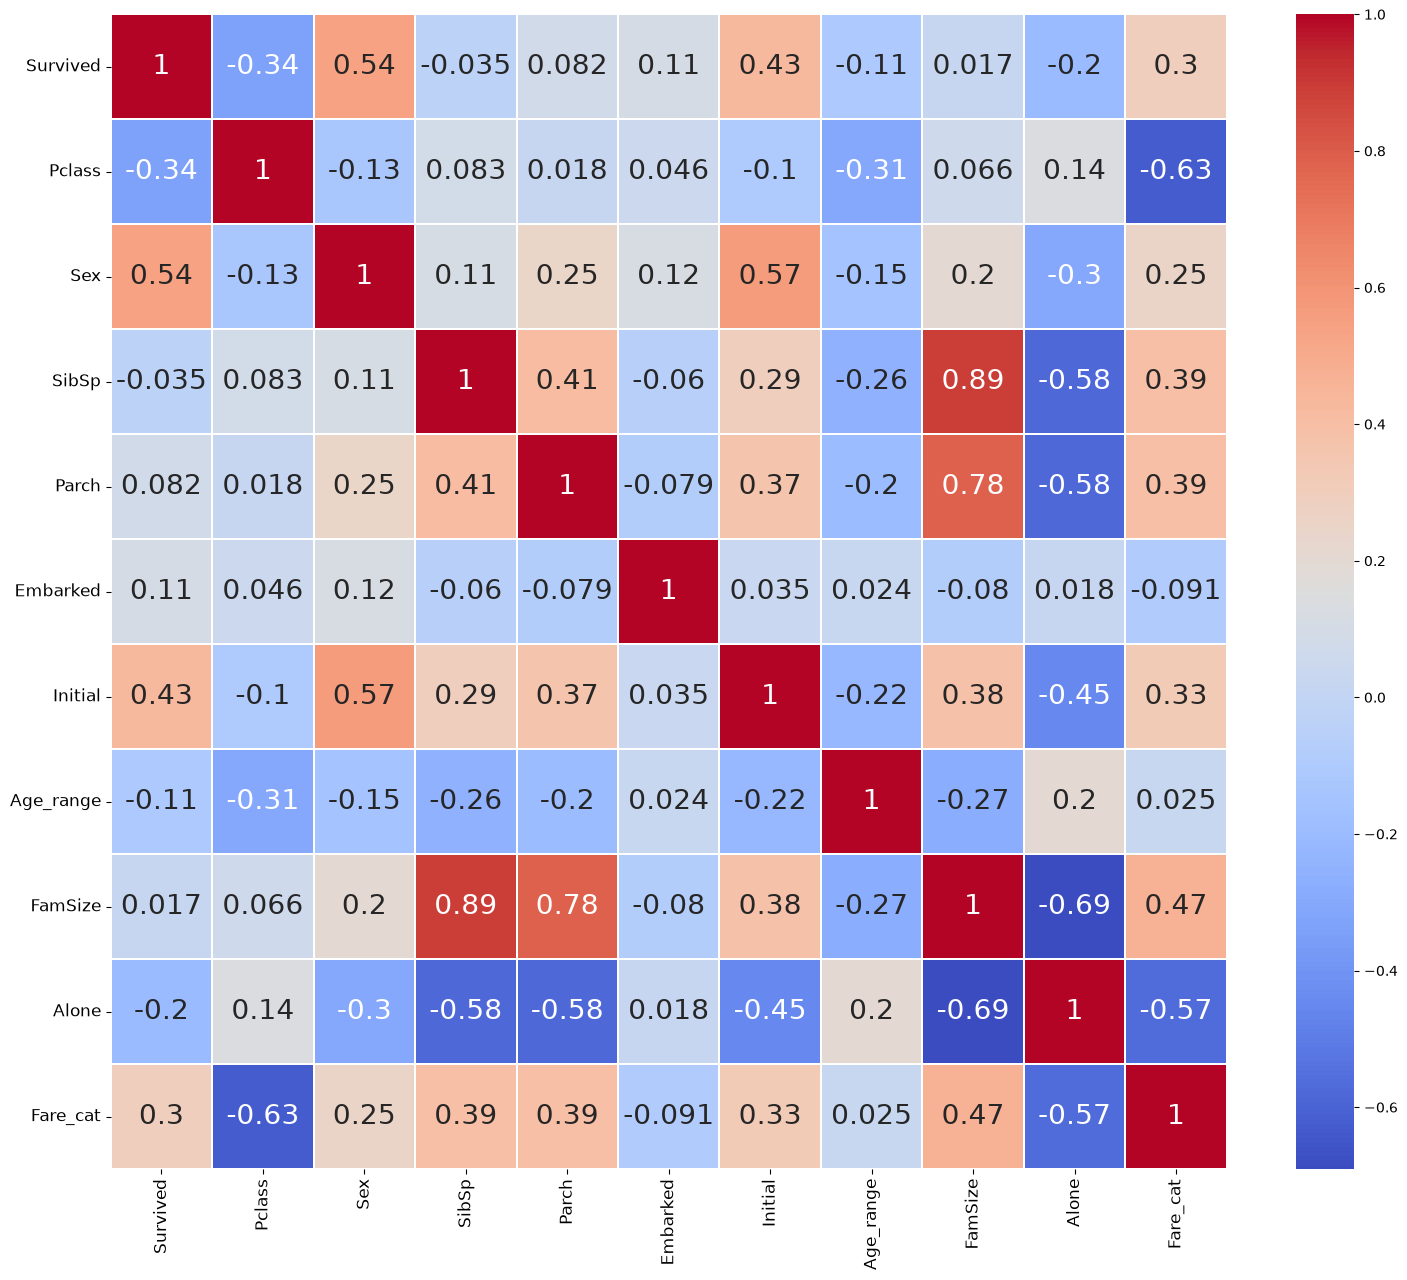

In [108]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.2, annot_kws={"size": 20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()